# Análise de Dados de Clientes de Cartão de Crédito

Este notebook tem o objetivo de explorar e analisar um conjunto de dados de clientes de cartão de crédito, que inclui informações demográficas, relacionamento e uso do cartão. A variável alvo default indica se o cliente inadimpliu. A análise busca identificar padrões e fatores associados à inadimplência.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_csv("/kaggle/input/projeto-python/Python_M11_support material.csv")
df.head()

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,na,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28


In [3]:
print(df.shape)
print(df.info())
print(df.describe(include="all").transpose())
print("Distribuição da variável alvo (default):")
print(df["default"].value_counts())

(10127, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       10127 non-null  int64 
 1   default                  10127 non-null  int64 
 2   idade                    10127 non-null  int64 
 3   sexo                     10127 non-null  object
 4   dependentes              10127 non-null  int64 
 5   escolaridade             10127 non-null  object
 6   estado_civil             10127 non-null  object
 7   salario_anual            10127 non-null  object
 8   tipo_cartao              10127 non-null  object
 9   meses_de_relacionamento  10127 non-null  int64 
 10  qtd_produtos             10127 non-null  int64 
 11  iteracoes_12m            10127 non-null  int64 
 12  meses_inativo_12m        10127 non-null  int64 
 13  limite_credito           10127 non-null  object
 14  valor_transacoes_12m     1

In [4]:
df["escolaridade"] = df["escolaridade"].replace("na", np.nan)
for col in ["limite_credito", "valor_transacoes_12m"]:
    df[col] = df[col].str.replace(".", "", regex=False)
    df[col] = df[col].str.replace(",", ".", regex=False)
    df[col] = df[col].astype(float)

df["qtd_transacoes_12m"] = df["qtd_transacoes_12m"].astype(int)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dtypes

id                           int64
default                      int64
idade                        int64
sexo                        object
dependentes                  int64
escolaridade                object
estado_civil                object
salario_anual               object
tipo_cartao                 object
meses_de_relacionamento      int64
qtd_produtos                 int64
iteracoes_12m                int64
meses_inativo_12m            int64
limite_credito             float64
valor_transacoes_12m       float64
qtd_transacoes_12m           int64
dtype: object

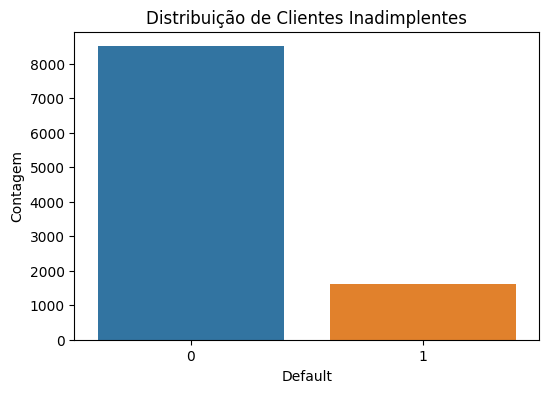

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


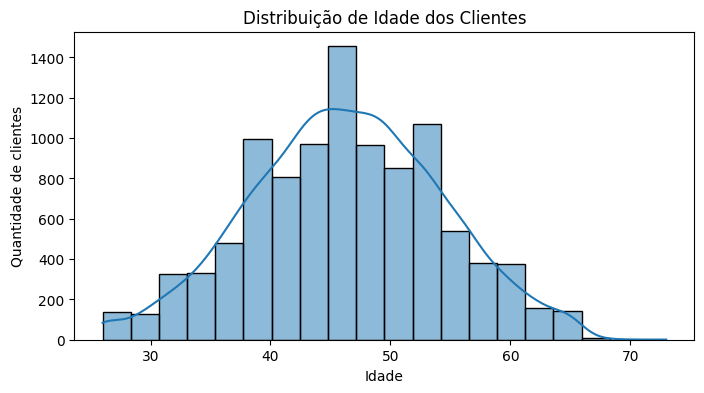

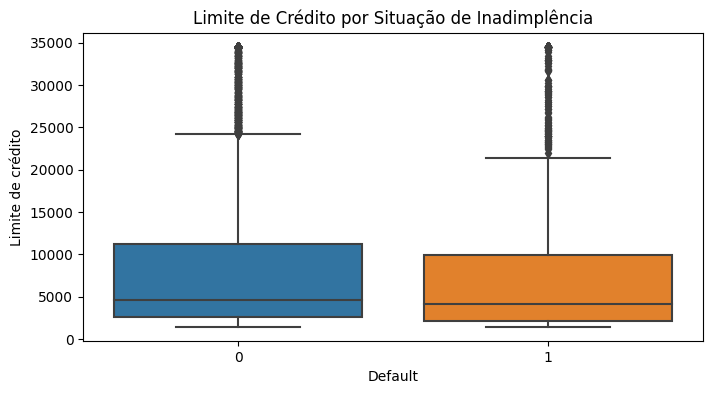

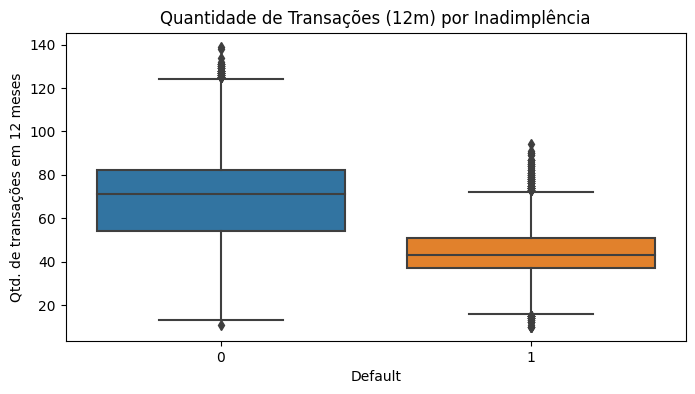

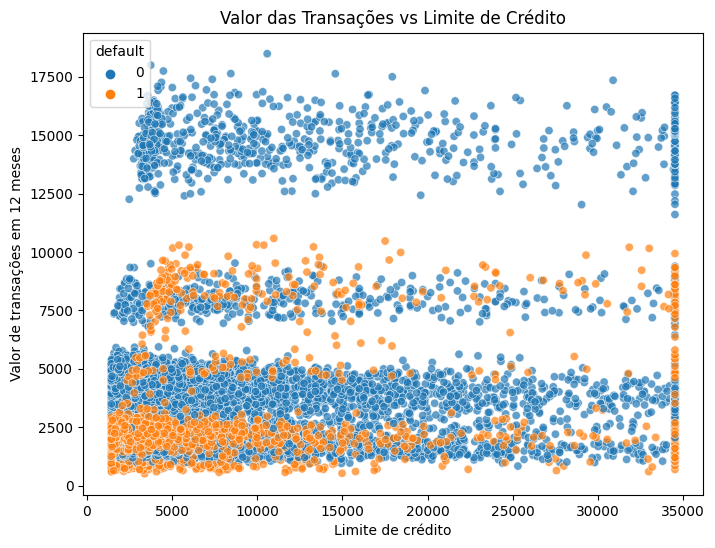

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="default", data=df)
plt.title("Distribuição de Clientes Inadimplentes")
plt.xlabel("Default")
plt.ylabel("Contagem")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df["idade"], bins=20, kde=True)
plt.title("Distribuição de Idade dos Clientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade de clientes")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x="default", y="limite_credito", data=df)
plt.title("Limite de Crédito por Situação de Inadimplência")
plt.xlabel("Default")
plt.ylabel("Limite de crédito")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x="default", y="qtd_transacoes_12m", data=df)
plt.title("Quantidade de Transações (12m) por Inadimplência")
plt.xlabel("Default")
plt.ylabel("Qtd. de transações em 12 meses")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x="limite_credito", y="valor_transacoes_12m", hue="default", data=df, alpha=0.7)
plt.title("Valor das Transações vs Limite de Crédito")
plt.xlabel("Limite de crédito")
plt.ylabel("Valor de transações em 12 meses")
plt.show()


## Resumo dos Insights

* A taxa geral de inadimplência é de aproximadamente 16%, indicando que a maioria dos clientes mantém suas contas em dia.
* Os clientes inadimplentes possuem, em média, um limite de crédito mais baixo e menos produtos contratados.
* O número de transações e o valor total transacionado nos últimos 12 meses é menor entre os clientes inadimplentes, enquanto o número de meses inativos e de interações é maior.
* A distribuição etária é semelhante entre inadimplentes e adimplentes, sem grandes variações na média de idade.
* Clientes do sexo feminino apresentaram uma taxa de inadimplência um pouco maior que os do sexo masculino.
* As faixas de salário entre 60K e 80K apresentaram a menor taxa de inadimplência, enquanto rendas muito altas ou muito baixas tiveram taxas ligeiramente mais elevadas.



## Storytelling

Imagine uma instituição financeira analisando sua base de clientes de cartão de crédito em busca de padrões de inadimplência. Ao longo da análise, percebe-se que a maioria dos clientes é adimplente, mas ainda assim há um grupo de cerca de 16% que deixa de pagar suas contas em dia.

O primeiro passo é olhar para quem são esses clientes inadimplentes: em média, eles têm limites de crédito menores, realizam menos transações e movimentam valores inferiores em comparação aos clientes adimplentes. São clientes com menor relação de engajamento, pois também têm menos produtos contratados.

Quando observamos fatores demográficos, percebemos que a idade não é um forte indicador de inadimplência: tanto inadimplentes quanto adimplentes têm média de idade em torno de 46 anos. Em relação ao sexo, nota-se uma diferença discreta, com mulheres apresentando um pouco mais de inadimplência do que homens.

O salário, por outro lado, apresenta uma relação não linear: pessoas com renda entre 60K e 80K têm a menor taxa de inadimplência, enquanto rendas extremas, muito altas ou muito baixas, apresentam índices um pouco maiores. Isso sugere que fatores comportamentais e de engajamento podem ser tão ou mais importantes que a capacidade financeira isolada.

Por fim, a educação formal também mostra variações: indivíduos com doutorado apresentaram a maior taxa de inadimplência, possivelmente por terem outros compromissos financeiros ou linhas de crédito.

Esses insights ajudam a instituição a direcionar estratégias de retenção e cobrança, focando não apenas em perfis financeiros, mas também em aumentar o engajamento dos clientes com produtos e serviços, reduzindo a inatividade e estimulando o uso regular do cartão. Ao entender melhor o perfil dos inadimplentes, é possível oferecer limites de crédito mais adequados, programas de fidelidade e ações de relacionamento que contribuam para diminuir o risco de inadimplência e melhorar a rentabilidade da carteira.
